In [1]:
import math
import polars as pl
import numpy as np
from pathlib import Path

from scipy.stats import pearsonr, spearmanr, multivariate_normal

from plotnine import (
    ggplot,
    aes,
    geom_line,
    theme,
    scale_color_identity,
    geom_rect,
    annotate,
    scale_y_continuous,
    facet_wrap,
    labs,
    scale_x_datetime,
    element_text,
    theme_538,
)

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [2]:
RAW_PATH = Path("data/raw")
PREPARED_PATH = Path("data/prepared")

In [4]:
def rad_to_deg(rad: float) -> float:
    return rad * 180 / math.pi

In [32]:
df = pl.read_parquet(PREPARED_PATH / "g_v02.parquet")
df.head()

raw_t_ms,t_ms,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc_norm,drink
i64,i64,f64,f64,f64,f64,f64,f64,f64,i64
100,100,-0.53,1.32,8.01,-0.25,0.0,-0.96,8.135318,0
100,200,1.3,0.21,8.74,0.28,-0.19,-0.55,8.838648,0
100,300,0.85,-0.42,9.49,0.02,-0.04,-0.52,9.537243,0
100,400,2.02,0.05,9.54,-0.25,-0.1,-0.28,9.751641,0
100,500,-1.03,-0.02,9.38,-0.48,0.04,0.1,9.436403,0


In [33]:
df = df.with_columns(
    pl.col("acc_norm").rolling_mean(window_size=10).alias("acc_norm_rolling"),
    pl.col("acc_x").rolling_mean(window_size=5).alias("acc_x_rolling"),
    pl.col("acc_z").rolling_mean(window_size=5).alias("acc_z_rolling"),
    pl.col("gyro_z").map_batches(lambda x: rad_to_deg(x)).alias("gyro_z_degrees"),
    pl.col("gyro_x")
    .map_batches(lambda x: rad_to_deg(x))
    .rolling_mean(window_size=5)
    .alias("gyro_y_degrees"),
    pl.col("gyro_x")
    .map_batches(lambda x: rad_to_deg(x))
    .rolling_mean(window_size=10)
    .alias("gyro_x_degrees"),
)
df.head()

raw_t_ms,t_ms,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc_norm,drink,acc_norm_rolling,acc_x_rolling,acc_z_rolling,gyro_z_degrees,gyro_y_degrees,gyro_x_degrees
i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64
100,100,-0.53,1.32,8.01,-0.25,0.0,-0.96,8.135318,0,null,null,null,-55.003948,null,null
100,200,1.3,0.21,8.74,0.28,-0.19,-0.55,8.838648,0,null,null,null,-31.512679,null,null
100,300,0.85,-0.42,9.49,0.02,-0.04,-0.52,9.537243,0,null,null,null,-29.793805,null,null
100,400,2.02,0.05,9.54,-0.25,-0.1,-0.28,9.751641,0,null,null,null,-16.042818,null,null
100,500,-1.03,-0.02,9.38,-0.48,0.04,0.1,9.436403,0,null,0.522,9.032,5.729578,-7.792226,null


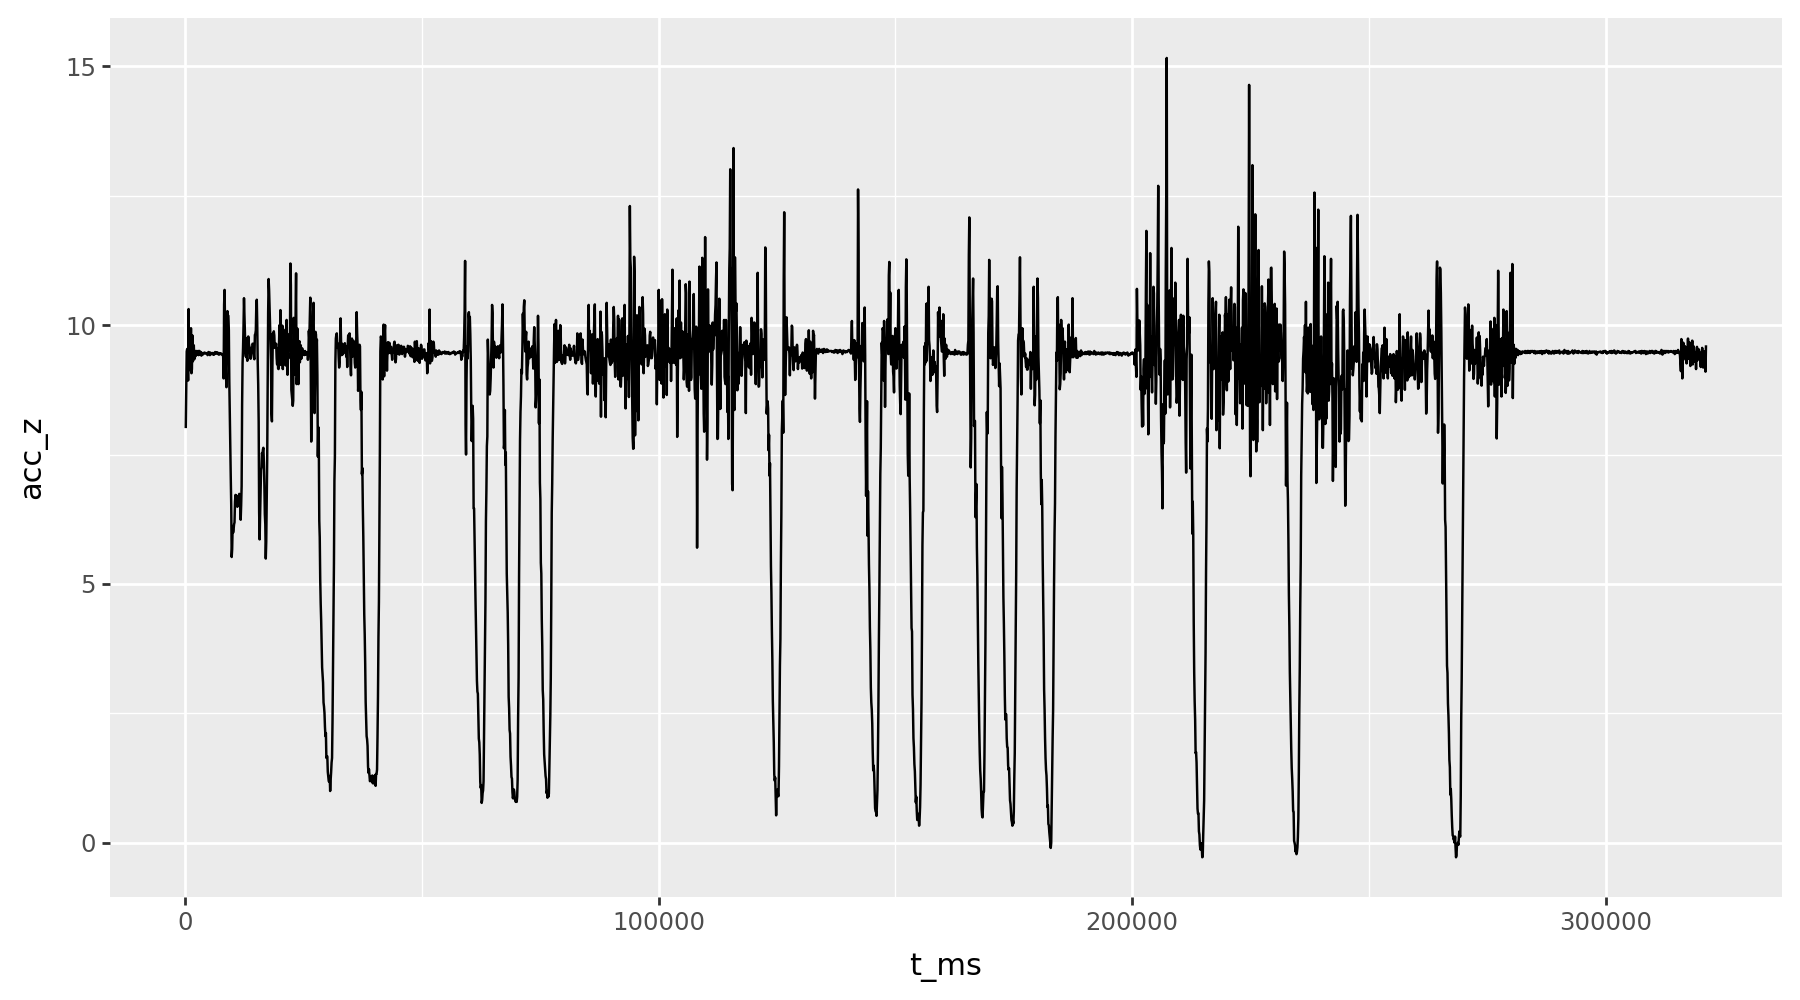

In [51]:
(ggplot(df, aes(x="t_ms", y="acc_z")) + geom_line() + theme(figure_size=(9, 5)))

In [35]:
df_test = df.with_columns(
    pl.when(pl.col("gyro_y") > 1.5)
    .then(1)
    .when(pl.col("gyro_y") < -1.5)
    .then(-1)
    .otherwise(0)
    .alias("gyro_y_square"),
    pl.when(pl.col("acc_x") < -5).then(1).otherwise(0).alias("acc_x_square"),
)
df_test.head()

raw_t_ms,t_ms,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc_norm,drink,acc_norm_rolling,acc_x_rolling,acc_z_rolling,gyro_z_degrees,gyro_y_degrees,gyro_x_degrees,gyro_y_square,acc_x_square
i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,i32,i32
100,100,-0.53,1.32,8.01,-0.25,0.0,-0.96,8.135318,0,null,null,null,-55.003948,null,null,0,0
100,200,1.3,0.21,8.74,0.28,-0.19,-0.55,8.838648,0,null,null,null,-31.512679,null,null,0,0
100,300,0.85,-0.42,9.49,0.02,-0.04,-0.52,9.537243,0,null,null,null,-29.793805,null,null,0,0
100,400,2.02,0.05,9.54,-0.25,-0.1,-0.28,9.751641,0,null,null,null,-16.042818,null,null,0,0
100,500,-1.03,-0.02,9.38,-0.48,0.04,0.1,9.436403,0,null,0.522,9.032,5.729578,-7.792226,null,0,0


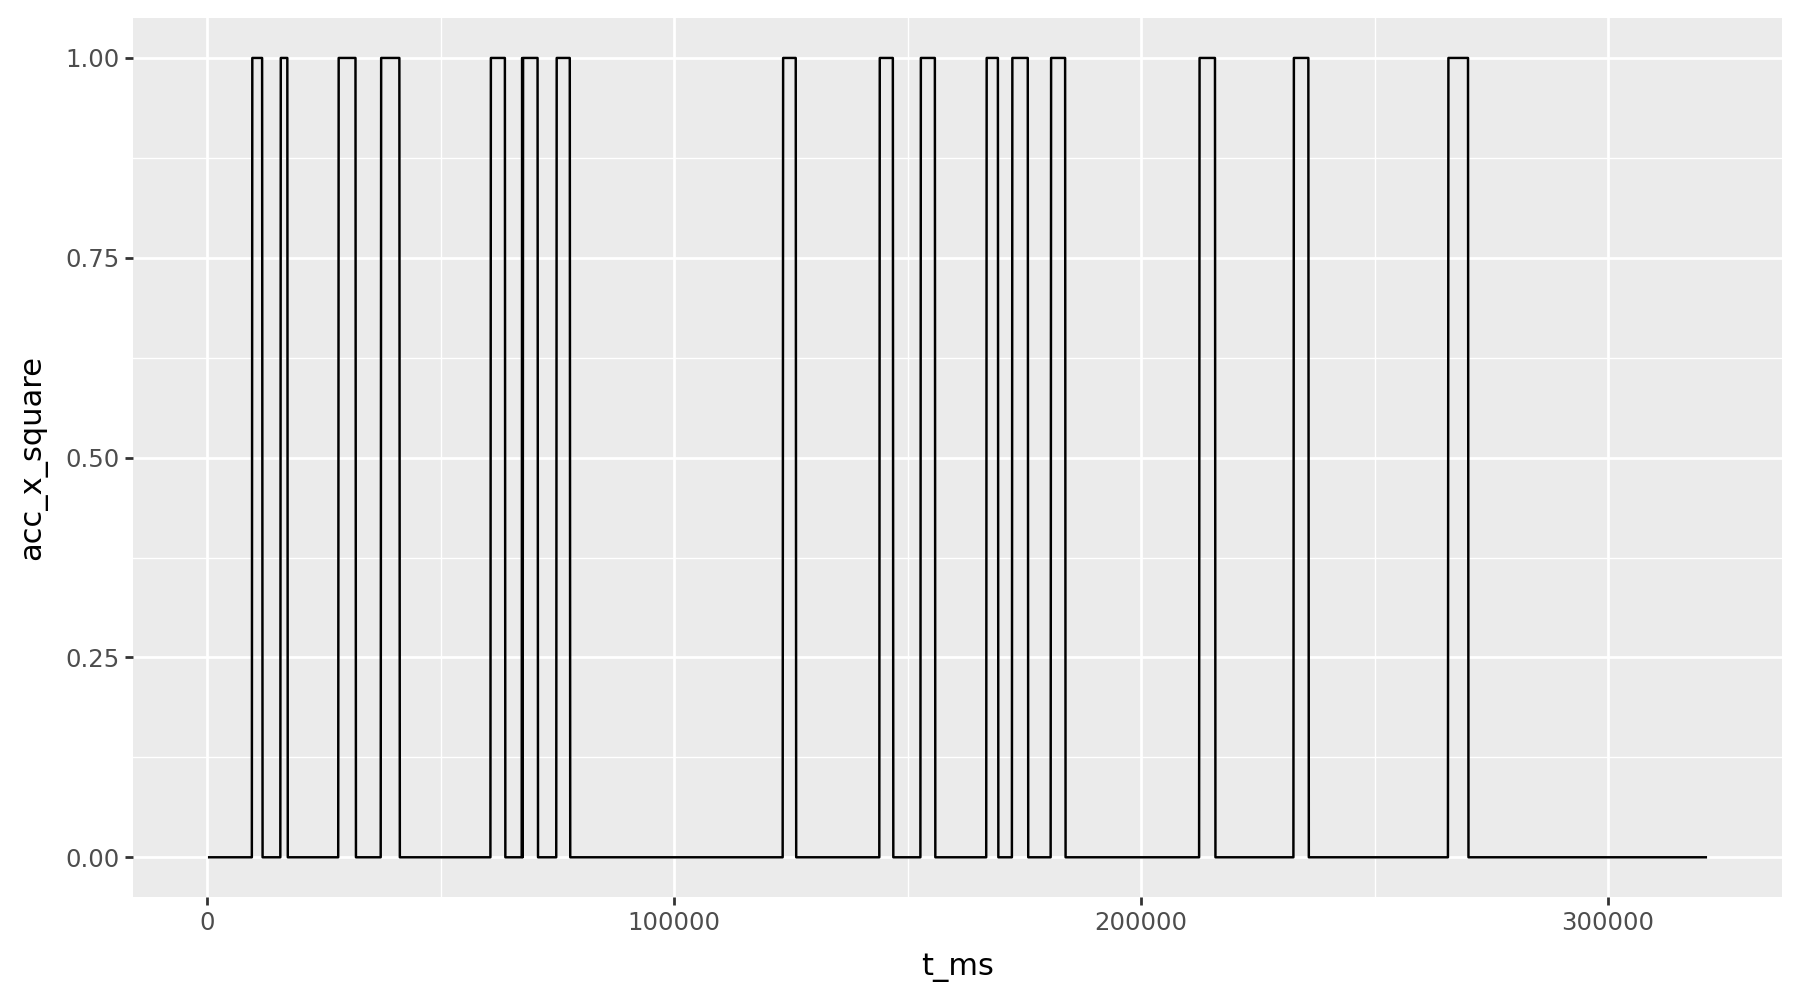

In [36]:
(
    ggplot(df_test, aes(x="t_ms", y="acc_x_square"))
    + geom_line()
    + theme(figure_size=(9, 5))
)

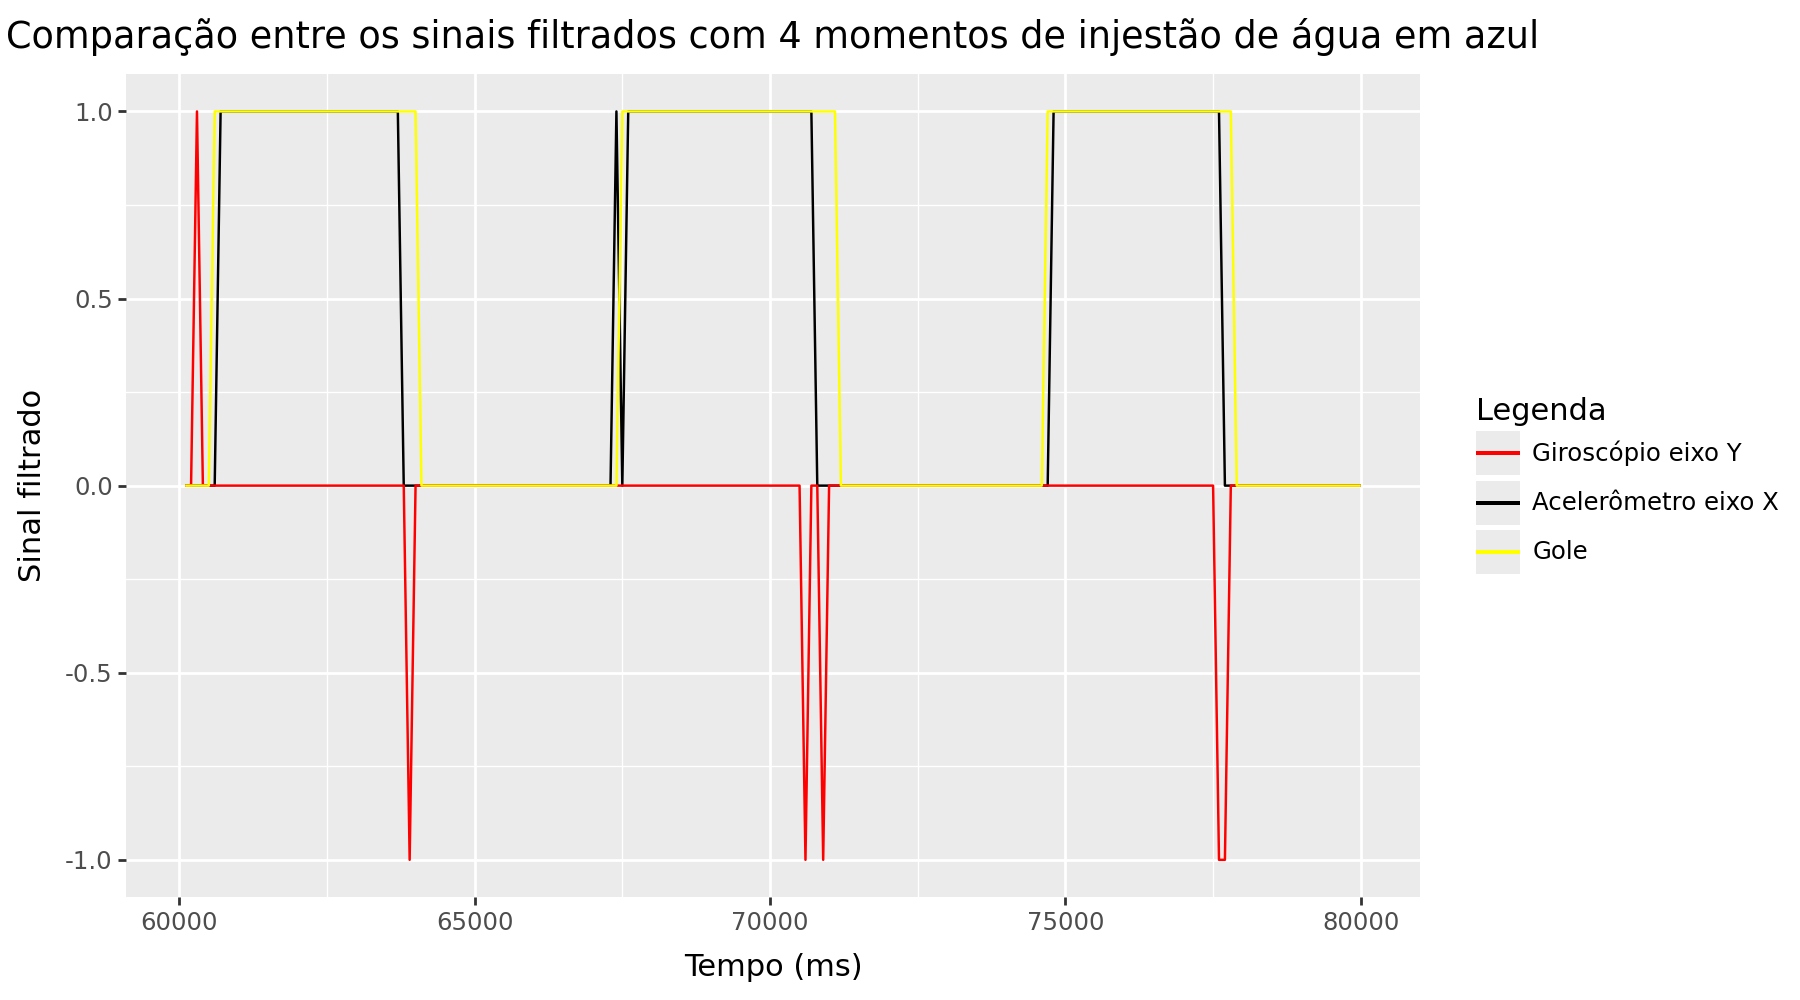

In [47]:
(
    ggplot(df_test[600:800], aes(x="t_ms"))
    + geom_line(aes(y="acc_x_square", color="'black'"))
    + geom_line(aes(y="gyro_y_square", color="'red'"))
    + geom_line(aes(y="drink", color="'yellow'"))
    + theme(figure_size=(9, 5))
    + labs(title="Comparação entre os sinais filtrados com 4 momentos de injestão de água em azul", x="Tempo (ms)", y="Sinal filtrado")
    + scale_color_identity(
        guide="legend",
        name="Legenda",
        breaks=["red", "black", "yellow"],
        labels=["Giroscópio eixo Y", "Acelerômetro eixo X", "Gole"],
    )
)

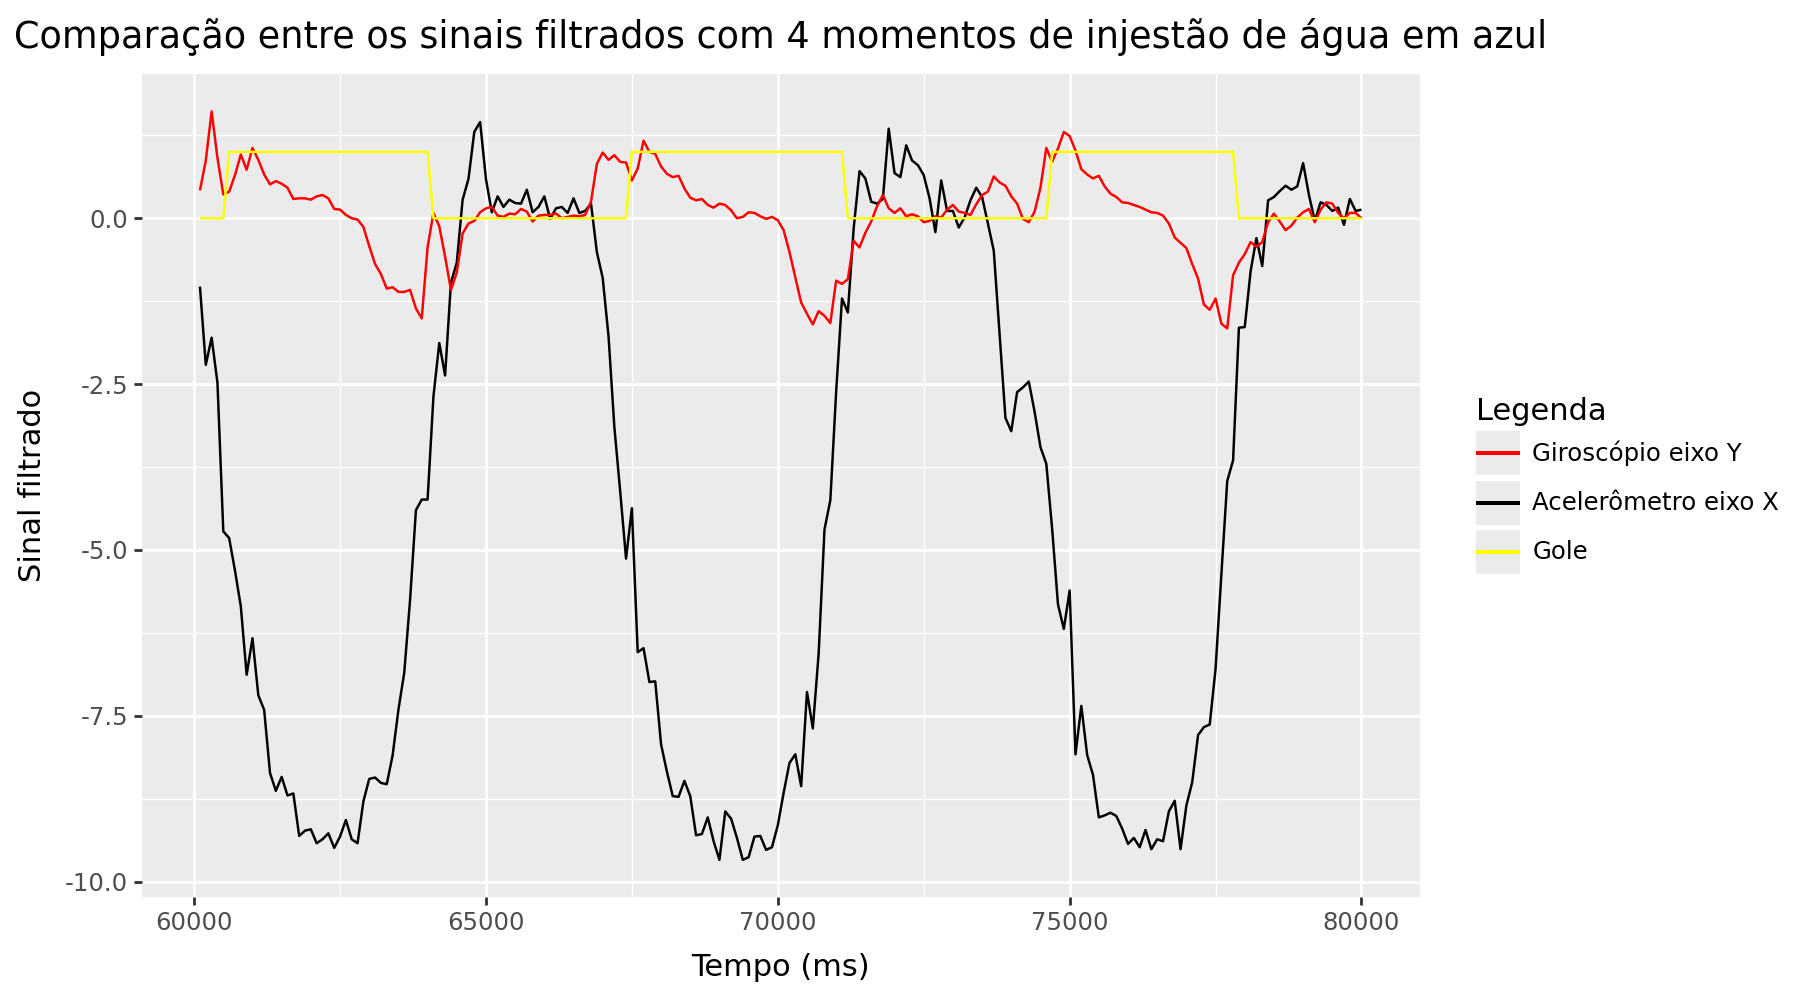

In [48]:
(
    ggplot(df_test[600:800], aes(x="t_ms"))
    + geom_line(aes(y="acc_x", color="'black'"))
    + geom_line(aes(y="gyro_y", color="'red'"))
    + geom_line(aes(y="drink", color="'yellow'"))
    + theme(figure_size=(9, 5))
    + labs(title="Comparação entre os sinais filtrados com 4 momentos de injestão de água em azul", x="Tempo (ms)", y="Sinal filtrado")
    + scale_color_identity(
        guide="legend",
        name="Legenda",
        breaks=["red", "black", "yellow"],
        labels=["Giroscópio eixo Y", "Acelerômetro eixo X", "Gole"],
    )
)

Two y axis

In [16]:
plt.style.use("ggplot")
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=80)

ax2 = ax1.twinx()
x = df_test["t_ms"].to_numpy()
y1 = df_test["acc_x_square"].to_numpy()
y2 = df_test["giro_y_square"].to_numpy()
ax1.plot(x, y1, "#50ad9f")
ax2.plot(x, y2, "black")

ax1.set_xlabel("X data")
ax1.set_ylabel("acc_x", color="#50ad9f")
ax2.set_ylabel("gyro_y", color="#0000a2")
ax1.grid(False)
ax2.grid(False)

plt.show()

ColumnNotFoundError: "giro_y_square" not found

In [50]:
for sensor in ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "acc_x_square", "gyro_y_square"]:
    print(f"Analisando sensor: {sensor}")
    coef, p_valor = pearsonr(df_test[sensor], df_test["drink"])
    print(f"Pearson: coef = {coef:.2f} p-valor = {p_valor:.2f}")
    coef_pearson, p_valor = spearmanr(df_test[sensor], df_test["drink"])
    print(f"Spearmanr: coef = {coef:.2f} p-valor = {p_valor:.2f}")

    cov_mat = np.stack((df_test[sensor], df_test["drink"]), axis = 0) 
    print(f"Covariancia: {np.cov(cov_mat)}\n")


Analisando sensor: acc_x
Pearson: coef = -0.89 p-valor = 0.00
Spearmanr: coef = -0.89 p-valor = 0.00
Covariancia: [[11.60660954 -1.13187387]
 [-1.13187387  0.13989892]]

Analisando sensor: acc_y
Pearson: coef = -0.50 p-valor = 0.00
Spearmanr: coef = -0.50 p-valor = 0.00
Covariancia: [[ 0.81423892 -0.17042723]
 [-0.17042723  0.13989892]]

Analisando sensor: acc_z
Pearson: coef = -0.82 p-valor = 0.00
Spearmanr: coef = -0.82 p-valor = 0.00
Covariancia: [[ 6.40792122 -0.77428551]
 [-0.77428551  0.13989892]]

Analisando sensor: gyro_x
Pearson: coef = -0.02 p-valor = 0.32
Spearmanr: coef = -0.02 p-valor = 0.09
Covariancia: [[ 0.07484068 -0.00180729]
 [-0.00180729  0.13989892]]

Analisando sensor: gyro_y
Pearson: coef = -0.09 p-valor = 0.00
Spearmanr: coef = -0.09 p-valor = 0.00
Covariancia: [[ 0.20488819 -0.0157817 ]
 [-0.0157817   0.13989892]]

Analisando sensor: gyro_z
Pearson: coef = 0.01 p-valor = 0.61
Spearmanr: coef = 0.01 p-valor = 0.02
Covariancia: [[0.37710338 0.00208121]
 [0.002081